# About Dataset

link https://www.kaggle.com/datasets/mhmd1424/sign-language-detection-dataset-5-classes/data

Overview: - This dataset contains 125 labeled images of sign language hand gestures across 5 classes: Yes No Hello I Love You Thank You
Since the dataset is relatively small, you can apply data augmentation during training (e.g., rotation, brightness, scaling) to increase its size and improve model generalization.

🖼 Format

YOLO detection format (images/, labels/, and data.yaml)

Already split into train / val / test sets

📌 Use Cases

Training sign language recognition models

Educational projects in computer vision

Accessibility AI research

Object detection practice with small, custom datasets

📍 Notes

Dataset was self-collected and annotated using MakeSense.ai

License: CC BY-SA 4.0 → free to use with attribution, including commercial use.

## Imports

In [1]:
!pip install mediapipe --quiet

In [2]:
import cv2
import joblib
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
import os
import yaml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model
from tqdm import tqdm


2025-11-03 15:39:50.524296: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762184390.546768    1208 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762184390.553568    1208 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Load The Data

In [3]:
dataset_base = "/kaggle/input/sign-language-detection-dataset-5-classes/Sign Language Detection"
yaml_path = os.path.join(dataset_base, "data.yaml")
images_base = os.path.join(dataset_base, "dataset_split/images")
labels_base = os.path.join(dataset_base, "dataset_split/labels")

# Load class names from data.yaml
with open(yaml_path, "r") as f:
    data_cfg = yaml.safe_load(f)
class_names = data_cfg["names"]
print("Classes:", class_names)

Classes: ['yes', 'no', 'hello', 'iloveyou', 'thankyou']


In [4]:
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=2, min_detection_confidence=0.5)

def extract_hand_features(img_path):
    """Extract 63 hand landmark features (x,y,z for 21 landmarks)"""
    img = cv2.imread(img_path)
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = hands.process(img_rgb)
    if not results.multi_hand_landmarks:
        return None

    hand_landmarks = results.multi_hand_landmarks[0]
    data = []
    for lm in hand_landmarks.landmark:
        data.extend([lm.x, lm.y, lm.z])
    return data

In [5]:
def process_dataset(split="train"):
    features, labels = [], []
    images_folder = os.path.join(images_base, split)
    labels_folder = os.path.join(labels_base, split)

    for img_file in os.listdir(images_folder):
        if not img_file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        img_path = os.path.join(images_folder, img_file)

        # Corresponding YOLO label file
        label_file = os.path.join(labels_folder, img_file.rsplit('.',1)[0] + ".txt")
        if not os.path.exists(label_file):
            continue

        with open(label_file, "r") as f:
            lines = f.readlines()
            if len(lines) == 0:
                continue
            class_id = int(lines[0].split()[0])
            label_name = class_names[class_id]

        feats = extract_hand_features(img_path)
        if feats:
            features.append(feats)
            labels.append(label_name)
    return np.array(features), np.array(labels)


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## Extract features for training set

In [6]:
# Extract features for training set
X, y = process_dataset(split="train")
print(f"Extracted features from {len(X)} images.")

# ------------------------------------------------------
# Encode labels and split
# ------------------------------------------------------
le = LabelEncoder()
y_enc = le.fit_transform(y)
y_cat = to_categorical(y_enc)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)


W0000 00:00:1762184393.733837    1268 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1762184393.765054    1268 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1762184393.816230    1268 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Extracted features from 87 images.
Train shape: (69, 63)
Validation shape: (18, 63)


## Model

In [7]:
from tensorflow.keras import Sequential, layers, regularizers, optimizers


num_features = X_train.shape[1]
num_classes  = len(class_names)

model = Sequential([
    layers.Input(shape=(num_features,)),

    # Dense block 1
    layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # Dense block 2
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # Dense block 3
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    # Output
    layers.Dense(num_classes, activation='softmax')
])

# Compile
opt = optimizers.Adam(learning_rate=1e-3)
model.compile(
    optimizer=opt,
    loss='categorical_crossentropy',   # (use one-hot y)
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1762184399.661105    1208 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,397 (232.02 KB)

 Trainable params: 58,629 (229.02 KB)

 Non-trainable params: 768 (3.00 KB)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
]

history = model.fit(
    X_train, y_train,                
    validation_data=(X_val, y_val),   
    epochs=200,
    batch_size=8,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/200


I0000 00:00:1762184402.431520    1283 service.cc:148] XLA service 0x7a9f0c00f050 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762184402.431554    1283 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1762184402.707438    1283 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.1250 - loss: 2.1605

I0000 00:00:1762184404.742095    1283 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 373ms/step - accuracy: 0.2456 - loss: 2.1946 - val_accuracy: 0.3333 - val_loss: 1.5989 - learning_rate: 0.0010
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3473 - loss: 1.8813 - val_accuracy: 0.2222 - val_loss: 1.5705 - learning_rate: 0.0010
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4370 - loss: 1.4678 - val_accuracy: 0.5000 - val_loss: 1.5341 - learning_rate: 0.0010
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5182 - loss: 1.1608 - val_accuracy: 0.5000 - val_loss: 1.5174 - learning_rate: 0.0010
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6036 - loss: 1.1121 - val_accuracy: 0.4444 - val_loss: 1.5022 - learning_rate: 0.0010
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7077 - loss: 0.7659 - val_accuracy: 0.5556 - val_loss: 1.4810 - learning_rate: 0.0010
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7348 - loss: 0.7484 - val_accuracy: 0.5556 - val_lo

## Learning curves

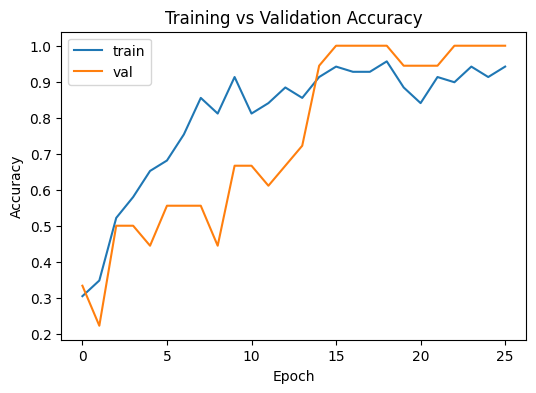

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.title('Training vs Validation Accuracy'); plt.show()
